# Import required packages

In [35]:
import json
from pathlib import Path
from pprint import pprint

import networkx as nx
from ipysigma import Sigma

# Open a JSON file containing the downloaded bibliographic records from a well-defined timeframe

In [36]:
date_range = "1851-1875"

file_path = Path.cwd() / "data" / "in" / f"nbt_index_{date_range}.json"
with file_path.open("r") as f:
    data = json.load(f)

# Extract the bibliographic catalogue data from the JSON

In [37]:
catalogue_items = data["results"]["bindings"]
item_dict_list = []

# Define edges and nodes for the graph representation of the bibliographic data

In [38]:
edges = []
nodes = {}

# Iterate through each bibliographic record and extract the relevant information

In [39]:
for x in catalogue_items:

    if x is not None:
        itemdata = x
        # Create a dictionary for each catalogue item
        item = {
            "uri": itemdata.get("uri").get("value"),
            "title": itemdata.get("name").get("value"),
            "language": itemdata.get("language").get("value"),
            "date": itemdata.get("jaar").get("value"),
            "pref_subject": itemdata.get("preflabel").get("value").lower() if itemdata.get("preflabel") is not None else None,
            "narrower_subject": itemdata.get("narrowerlabel").get("value").lower() if itemdata.get("narrowerlabel") is not None else None,
            "broader_subject": itemdata.get("broaderlabel").get("value").lower() if itemdata.get("broaderlabel") is not None else None,
        }
        item_dict_list.append(item)

        # Define edges for the catalogue graph
        # Add edges based on the relationships between titles and subjects
        # and between subjects themselves (broader and narrower)
        if item["pref_subject"] is not None:
            edges.append((item["pref_subject"], item["title"]))
        if item["narrower_subject"] is not None:
            edges.append((item["pref_subject"], item["narrower_subject"]))
            edges.append((item["narrower_subject"], item["title"]))
        if item["broader_subject"] is not None:
            edges.append((item["pref_subject"], item["broader_subject"]))
            edges.append((item["broader_subject"], item["title"]))

        # Define nodes for the catalogue graph
        keys_title_to_extract = ["title", "pref_subject", "narrower_subject", "broader_subject", "date", "language", "uri"]
        keys_subject_to_extract = ["pref_subject", "narrower_subject", "broader_subject"]
        for node_attributes in item_dict_list:
            node_title = node_attributes["title"]
            node_pref_subject = node_attributes["pref_subject"]
            node_narrower_subject = node_attributes["narrower_subject"]
            node_broader_subject = node_attributes["broader_subject"]

            # Create sub-dictionaries for title and subject nodes with relevant attributes
            sub_dict_title = {key: node_attributes[key] for key in keys_title_to_extract if key in node_attributes}
            sub_dict_title["type"] = "book"
            sub_dict_subject = {key: node_attributes[key] for key in keys_subject_to_extract if key in node_attributes}
            sub_dict_subject["type"] = "subject"
            
            nodes[node_title] = sub_dict_title
            if node_pref_subject is not None:
                nodes[node_pref_subject] = sub_dict_subject
            if node_narrower_subject is not None:
                nodes[node_narrower_subject] = sub_dict_subject
            if node_broader_subject is not None:
                nodes[node_broader_subject] = sub_dict_subject

# Inspect nodes and edges

In [40]:

# Print the first 5 edges for verification
pprint("*****")
pprint("* Inspect The first 5 edges:")
pprint("*****")
pprint(edges[:5])
print("\n")
# Print the first 5 nodes for verification
pprint("*****")
pprint("* Inspect The first 5 nodes:")
pprint("*****")
pprint(dict(list(nodes.items())[:5]))

'*****'
'* Inspect The first 5 edges:'
'*****'
[('psychologie',
  'Hoe en waardoor zich in den menschlijken geest de vrijheid openbaart en '
  'ontwikkelt'),
 ('psychologie', 'gedragswetenschappen'),
 ('gedragswetenschappen',
  'Hoe en waardoor zich in den menschlijken geest de vrijheid openbaart en '
  'ontwikkelt'),
 ('psychology',
  'Hoe en waardoor zich in den menschlijken geest de vrijheid openbaart en '
  'ontwikkelt'),
 ('psychology', 'gedragswetenschappen')]


'*****'
'* Inspect The first 5 nodes:'
'*****'
{'Bijdragen ter verdediging van de echtheid der Johanneïsche schriften': {'broader_subject': 'inleiding '
                                                                                              'en '
                                                                                              'exegese',
                                                                           'date': '1852',
                                                                           'l

# Draw NetworkX Graph

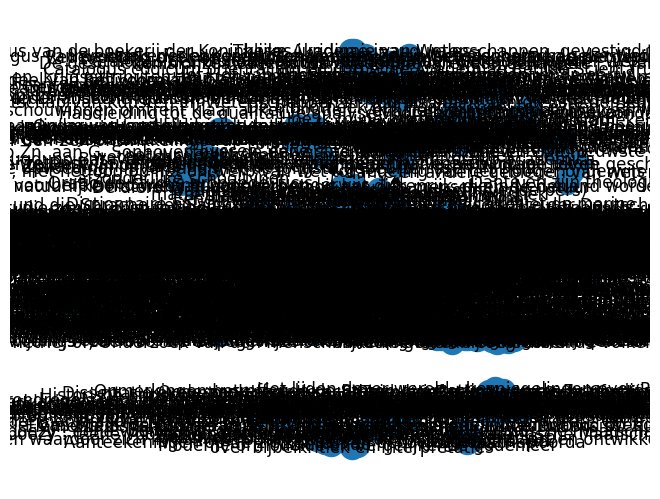

In [29]:
G = nx.DiGraph()
for edge in edges:
    G.add_edge(edge[0], edge[1])

nx.set_node_attributes(G, nodes)
nx.draw(G, with_labels=True)

# Create a Sigma visualization

In [30]:
Sigma(
    G,
    node_metrics=["louvain"],
    node_color="pref_subject",
    node_size_range=(3, 30),
    node_shape = "type",
    node_shape_mapping = {
        "book": "book_2",
        "subject": "label"
        },
    max_categorical_colors=50,
    default_edge_type="curve",
    default_node_label_size=14,
    node_size=G.degree,
    label_density=2
    )

Sigma(nx.DiGraph with 774 nodes and 2,822 edges)